##### ARTI 560 - Computer Vision  
## Image Classification using Transfer Learning - Exercise 

### Objective

In this exercise, you will:

1. Select another pretrained model (e.g., VGG16, MobileNetV2, or EfficientNet) and fine-tune it for CIFAR-10 classification.  
You'll find the pretrained models in [Tensorflow Keras Applications Module](https://www.tensorflow.org/api_docs/python/tf/keras/applications).

2. Before training, inspect the architecture using model.summary() and observe:
- Network depth
- Number of parameters
- Trainable vs Frozen layers

3. Then compare its performance with ResNet and the custom CNN.

### Questions:

- Which model achieved the highest accuracy?
- Which model trained faster?
- How might the architecture explain the differences?

In [20]:
#Importing libraries
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical

#Importinh dataset
from tensorflow.keras.datasets import cifar10

In [21]:
#Loading the dataset / CIFAR-10 data
(x_train, y_train) , (x_test, y_test) = cifar10.load_data()

In [22]:
#Checkeing dataset shapes
print(f'x_train shape: {x_train.shape}') #(50000, 32, 32, 3)
print(f'y_train shape: {y_train.shape}') #(50000, 1)
print(f'x_test shape: {x_test.shape}') #(50000, 32, 32, 3)
print(f'y_test shape: {y_test.shape}') #(50000, 1)

x_train shape: (50000, 32, 32, 3)
y_train shape: (50000, 1)
x_test shape: (10000, 32, 32, 3)
y_test shape: (10000, 1)


In [23]:
#Checkeing number of unique classes
num_classes = len(np.unique(y_train))
print(f'Number of classes: {num_classes}') #should be 10

Number of classes: 10


In [24]:
#Define class names for easy reference
class_names = ["airplane", "automobile", "bird", "cat", "deer", 
               "dog", "frog", "horse", "ship", "truck"]

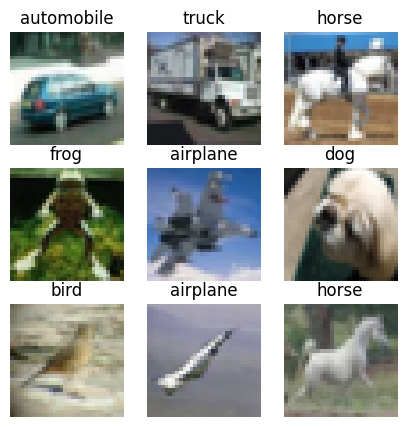

In [25]:
#Plotting random images from dataset with thier labels
plt.figure(figsize = (5, 5))
for i in range (9):
    index = np.random.randint(0, len(x_train))
    plt.subplot(3, 3, i+1)
    plt.imshow(x_train[index])
    plt.title(class_names[y_train[index][0]])
    plt.axis('off')
plt.show()

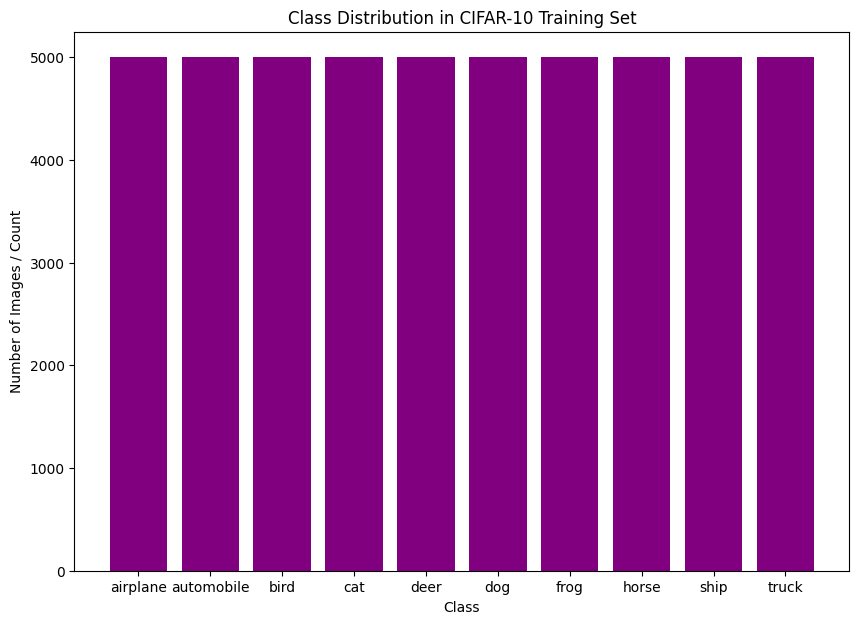

In [26]:
#Viweing count occurrences of each class in the training set
class_counts = np.bincount(y_train.flatten())

plt.figure(figsize = (10, 7))
plt.bar(class_names, class_counts, color = 'purple')
plt.title('Class Distribution in CIFAR-10 Training Set')
plt.xlabel('Class')
plt.ylabel('Number of Images / Count')
plt.show()

In [27]:
print(f'Maximun pixel value: {x_train.min()}') #printing minimum pixel value
print(f'Minimum pixel value: {x_train.max()}') #printing maximum pixel value

Maximun pixel value: 0
Minimum pixel value: 255


In [28]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications.efficientnet_v2 import EfficientNetV2S
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

#labels are integer
y_train = y_train.squeeze().astype('int64')
y_test = y_test.squeeze().astype('int64')

#images to float32
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

In [29]:
#Data augmentation
data_augmentation = keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
], name = 'augmentation')

In [31]:
efficientnet_base = EfficientNetV2S(
    include_top = False,
    weights = 'imagenet',
    input_shape = (224, 224, 3) #expected input size for the EfficientNet is 224x224 , 3 because RGB
)
efficientnet_base.trainable = False #Feature Exctracting - freezing backbone!

82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
efficientnet_model = keras.Sequential([
    layers.Input(shape = (32, 32, 3)), #CIFAR images shape
    data_augmentation,
    layers.Resizing(224, 224, interpolation = 'bilinear'),  #applying interpolation as I ams resizing from 32x32 to 224x224
    layers.Lambda(preprocess_input),
    efficientnet_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(10) #10 classes in CIFAR10
], name = 'cifar10_efficientnetv2s')

efficientnet_model.summary()

Model: "cifar10_efficientnetv2s"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ augmentation (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_1 (Resizing)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 7, 7, 1280)     │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,344,170 (77.61 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 20,331,360 (77.56 MB)

In [36]:
efficientnet_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate = 1e-3),
    loss = keras.losses.SparseCategoricalCrossentropy(from_logits = True),
    metrics = ['accuracy']
)

callbacks = [
    keras.callbacks.EarlyStopping(monitor = 'val_accuracy', patience = 3, restore_best_weights = True),
    keras.callbacks.ReduceLROnPlateau(monitor = 'val_loss', factor = 0.5, patience = 1),
]

history = efficientnet_model.fit(
    x_train, y_train,
    validation_split = 0.1,
    epochs = 3,
    batch_size = 64,
    callbacks = callbacks,
    verbose = 1
)

Epoch 1/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 249s 319ms/step - accuracy: 0.7017 - loss: 0.9497 - val_accuracy: 0.9108 - val_loss: 0.2929 - learning_rate: 0.0010
Epoch 2/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 236s 336ms/step - accuracy: 0.8055 - loss: 0.5748 - val_accuracy: 0.9148 - val_loss: 0.2694 - learning_rate: 0.0010
Epoch 3/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 239s 340ms/step - accuracy: 0.8168 - loss: 0.5405 - val_accuracy: 0.9160 - val_loss: 0.2641 - learning_rate: 0.0010


In [37]:
test_loss, test_acc_r = efficientnet_model.evaluate(x_test, y_test, verbose = 0)
print("EfficientNetV2S (frozen) test accuracy:", test_acc_r)
print("EfficientNetV2S (frozen) test loss    :", test_loss)

EfficientNetV2S (frozen) test accuracy: 0.9139999747276306
EfficientNetV2S (frozen) test loss    : 0.2702964246273041


In [40]:
#Total number of layers inside the EfficientNetV2S backbone
print('Total number of layers in EfficientNetV2S backbone: ', len(efficientnet_base.layers))

#Filtering ONLY layers that actually have learnable parameters (weights/biases)
trainable_layers = [layer for layer in efficientnet_base.layers if layer.count_params() > 0 ]

#Printing the number of layers that contain learnable parameters ((Depth of the Model))
print('Total Layers with learnable parameters (Depth): ', len(trainable_layers))

Total number of layers in EfficientNetV2S backbone:  513
Total Layers with learnable parameters (Depth):  280


In [41]:
# Listing all layers that have learnable parameters (trainable_layers)
# Each layer will be printed with (index in the filtered list, layer name, number of parameters)
for i, layer in enumerate(trainable_layers):
    print(i, layer.name, layer.count_params())

0 stem_conv 648
1 stem_bn 96
2 block1a_project_conv 5184
3 block1a_project_bn 96
4 block1b_project_conv 5184
5 block1b_project_bn 96
6 block2a_expand_conv 20736
7 block2a_expand_bn 384
8 block2a_project_conv 4608
9 block2a_project_bn 192
10 block2b_expand_conv 82944
11 block2b_expand_bn 768
12 block2b_project_conv 9216
13 block2b_project_bn 192
14 block2c_expand_conv 82944
15 block2c_expand_bn 768
16 block2c_project_conv 9216
17 block2c_project_bn 192
18 block2d_expand_conv 82944
19 block2d_expand_bn 768
20 block2d_project_conv 9216
21 block2d_project_bn 192
22 block3a_expand_conv 82944
23 block3a_expand_bn 768
24 block3a_project_conv 12288
25 block3a_project_bn 256
26 block3b_expand_conv 147456
27 block3b_expand_bn 1024
28 block3b_project_conv 16384
29 block3b_project_bn 256
30 block3c_expand_conv 147456
31 block3c_expand_bn 1024
32 block3c_project_conv 16384
33 block3c_project_bn 256
34 block3d_expand_conv 147456
35 block3d_expand_bn 1024
36 block3d_project_conv 16384
37 block3d_proj

In [46]:
#Fine-tuning
efficientnet_base.trainable = True
for layer in efficientnet_base.layers[:-30]: #Unfreezing last 30 layers
    layer.trainable = False #Keeping first layers Frozen

print('Trainable layers in backbone: ', sum(l.trainable for l in efficientnet_base.layers), '/', len(efficientnet_base.layers))

Trainable layers in backbone:  30 / 513


In [47]:
efficientnet_model.compile(
    optimizer = keras.optimizers.Adam(learning_rate = 1e-5),
    loss = keras.losses.SparseCategoricalCrossentropy(from_logits = True),
    metrics = ["accuracy"]
)

history_ft = efficientnet_model.fit(
    x_train, y_train,
    validation_split = 0.1,
    epochs = 3,
    batch_size = 64,
    verbose = 1
)

Epoch 1/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 291s 379ms/step - accuracy: 0.8023 - loss: 0.5747 - val_accuracy: 0.9136 - val_loss: 0.2734
Epoch 2/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 261s 371ms/step - accuracy: 0.8222 - loss: 0.5341 - val_accuracy: 0.9156 - val_loss: 0.2600
Epoch 3/3
704/704 ━━━━━━━━━━━━━━━━━━━━ 262s 372ms/step - accuracy: 0.8285 - loss: 0.5021 - val_accuracy: 0.9198 - val_loss: 0.2489


In [48]:
test_loss_ft, test_acc_ft = efficientnet_model.evaluate(x_test, y_test, verbose = 0)
print("EfficientNetV2S (fine-tuned) test accuracy:", test_acc_ft)
print("EfficientNetV2S (fine-tuned) test loss    :", test_loss_ft)

EfficientNetV2S (fine-tuned) test accuracy: 0.9180999994277954
EfficientNetV2S (fine-tuned) test loss    : 0.25195181369781494


### Answering The Questions:

- Which model achieved the highest accuracy?

EfficientNetV2S (fine-tuned to be specific) achieved the highest accuracy (91.81%) outperforming the accuracy of ResNet50V2 (fine-tuned also) which was (91.61%)

- Which model trained faster?

Custom CNN is the fastest because it is small model with few parameters and no pretraining unlike ResNet and EfficientNet
Between pretrained models, EfficientNetV2S trained faster than ResNet50V2 because its architecture was optimized for efficiency

- How might the architecture explain the differences?

Custom CNN had the lowest accuracy because it is a shallow network and was trained from scratch and no pretrained knowledge. All that resulted in lowest accuracy
ResNet50V2 is a deep network with residual connections. It also prevents vanishing gradients and was pretrained on ImageNet dataset so it has strong feature extraction
EfficientNetV2S is also a deep network and was ppretrained on ImageNet dataset so it has strong feature extraction as well, what makes it even better is that it was built specifically for faster training and better scaling efficiency